<a href="https://colab.research.google.com/github/IsaacFigNewton/CommitteeHearingDiscourseParser/blob/main/DH2024_DigitalDemocracy_Demo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Accessing & working with the Digital Democracy Corpus: Comprehensive Proceedings of Four State Legislatures 2015-2018


This notebook will act as a guide for a person with minimal knowledge of coding to make use of the files and retrieve useful information from the corpus.


The dataset can be downloaded directly from this website: https://huggingface.co/datasets/iatpp/digitaldemocracy-2015-2018

This corpus is distributed under the cc-by-nc-sa-4.0 license. Please review before accessing. https://creativecommons.org/licenses/by-nc-sa/4.0/

Please cite as:

Khosmood, F., Dekhtyar, A., Ellwein, S., White, B., "The Digital Democracy Corpus: Comprehensive Proceedings of Four State Legislatures 2015-2018", Digital Humanities, Washington, DC, August 2024.

# Download files

The Digital Democracy Corpus can be downloaded from here: https://huggingface.co/datasets/iatpp/digitaldemocracy-2015-2018

In [1]:
from pathlib import Path
import subprocess
import zipfile
import os

#This is where the unzipped corpus file is stored
CORPUS_FILE_PATH = 'DH2024_Corpus_Release/'
corpus_dir = Path(CORPUS_FILE_PATH)
zip_path = Path("digitaldemocracy-2015-2018/DH2024_Corpus_Release.zip")
repo_dir = Path("digitaldemocracy-2015-2018")

# Clone repository if not present
if not repo_dir.is_dir():
    print("Corpus directory not found. Cloning repository...")
    subprocess.run(
        ["git", "clone", "https://huggingface.co/datasets/iatpp/digitaldemocracy-2015-2018"],
        check=True,
    )
    print("Repository cloned successfully.")

# Extract zip file if corpus directory doesn't exist
if not corpus_dir.is_dir():
    if zip_path.exists():
        print(f"Extracting {zip_path}...")
        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            zip_ref.extractall('.')
        print("Extraction complete.")
    else:
        print(f"Error: {zip_path} not found!")
else:
    print(f"Corpus already extracted at {corpus_dir}")

Corpus already extracted at DH2024_Corpus_Release


# Import and config

In [2]:
from src import HearingLoader, HearingTagger, ClassifierPipeline
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier

text_features = [ClassifierPipeline.TEXT_COL]
categorical_features = ClassifierPipeline.CAT_COLS
numeric_features = ClassifierPipeline.NUM_COLS

# Initialize the HearingLoader with the corpus path
loader = HearingLoader(corpus_path='DH2024_Corpus_Release/')
tagger = HearingTagger()

# Create classifiers
lr_classifier = LogisticRegression(
    max_iter=2000,
    class_weight='balanced',
    solver='lbfgs'
)

mlp_classifier = MLPClassifier(
    hidden_layer_sizes=(10, 10),
    max_iter=2000,
    random_state=42,
    solver='adam'
)

# Create parsers with different classifiers
parser_lr = ClassifierPipeline(base_estimator=lr_classifier)
parser_mlp = ClassifierPipeline(base_estimator=mlp_classifier)

# Discussion Transcripts

In [3]:
# discussion will contain all the information from bill CA_201720180AB10 in hearing id 51835
# 'CA_201720180AB10': ['51835',
#   '52298',
#   '52708',
#   '52856',
#   '53960',
#   '54363',
#   '54505']
hearing = loader.bill_discussion_info(51835, "CA_201720180AB10")
print(hearing)

State:		CA
Committee:	Assembly Standing Committee on Education
Bill:		CA_201720180AB10
Date:		2017-03-15


Transcript:
Patrick O'Donnell: [UNKNOWN]:
She'll be presenting AB 10, file item number one.


Cristina Garcia: [UNKNOWN]:
Thank you. Good afternoon Chair and members. I'm here presenting AB 10 would require vital menstrual products, pads, and tampons to be provided in school, colleges, shelters throughout the state. Menstrual products are a basic necessity similar to toilet paper. As early as the fourth grade young girls get their period and may not be prepared nor understand the natural changes of their bodies many of these young girls end up missing school three to five days a month on a regular basis, because they lack basic access to these products. No young girl should ever have to miss school because she does not have access to these basic health needs. For some young girls, access to these products is an additional barrier to their education. It's also loss of funding for s

# Try loading all the hearings

In [4]:
hearings = loader.load_all_committee_hearings()
relevant_hearings = [h for h in hearings if h.bid != 'CA_NO BILL DISCUSSED']
print(len(hearings))
print(len(relevant_hearings))

invalid literal for int() with base 10: 'hid'
invalid literal for int() with base 10: 'hid'
invalid literal for int() with base 10: 'hid'
8218
7069


In [5]:
import random

# Set random seed for reproducibility
random.seed(42)

# Randomly sample 100 hearings
sampled_hearings = random.sample(relevant_hearings, 100)
sampled_hearings = [tagger(h) for h in sampled_hearings]

# Build utterances dataframe from the sampled hearings using the new public method
# This automatically sorts by state, bid, hid, uid and fills missing values
utterances_df = parser_lr.build_utterances_dataframe(sampled_hearings)

# save it to a csv
utterances_df.to_csv('./utterances_sample.csv', index=False)

In [6]:
import pandas as pd

utterances_df = pd.read_csv('./utterances_sample.csv')
labeled_utterances_df = pd.read_csv('./utterances_sample_labeled.csv')

# labeled_utterances_df = labeled_utterances_df[[
#     "state","bid","hid","uid","pid",
#     "speaker.position","section",
#     "text"
# ]]
# labeled_utterances_df.to_csv('./utterances_sample_labeled2.csv', index=False)

In [7]:
feature_cols = [
    c for c in utterances_df.columns
    if c not in labeled_utterances_df
    and c != "speaker.position.value"
]
labeled_utterances_df[feature_cols] = utterances_df[feature_cols]

In [8]:
labeled_utterances_df.head()

,state,bid,hid,uid,pid,speaker.position,section,text,speaker.position_value,can_file_motions,is_presenter,relative_position,sent_count,mentions_speaker,mentions_bill,speech_act_cues,section_cues
0,CA,CA_201520160AB2050,255341,0,55,PRESIDING_CHAIR,INTRO,ORG woman LEGISLATOR you have three matters if...,8.0,True,False,0.000000,5,1,1,NaN,NaN
1,CA,CA_201520160AB2050,255341,1,101330,BILL_AUTHOR,PRESENTATION,good morning mr chair and members thank you fo...,4.0,False,True,0.022727,18,0,1,NaN,NaN
2,CA,CA_201520160AB2050,255341,2,55,PRESIDING_CHAIR,PRESENTATION,that is correct what they've been doing we've ...,8.0,True,False,0.045455,3,0,0,NaN,NaN
3,CA,CA_201520160AB2050,255341,3,101330,BILL_AUTHOR,PRESENTATION,that's correct,4.0,False,True,0.068182,1,0,0,NaN,NaN
4,CA,CA_201520160AB2050,255341,4,55,PRESIDING_CHAIR,PRESENTATION,and this is plan step two I guess or new step two,8.0,True,False,0.090909,1,0,0,NaN,NaN


In [9]:
labeled_utterances_df['section'].value_counts()

section
LEGISLATOR_DISCUSSION    987
PUBLIC_COMMENTS          841
VOTE                     335
OTHER                    131
PRESENTATION             113
EXPERT_TESTIMONY         102
INTRO                     71
CLOSING_REMARKS           39
Name: count, dtype: int64

In [10]:
# Fill missing values in the labeled data loaded from CSV
labeled_utterances_df['text'] = labeled_utterances_df['text'].fillna('')
labeled_utterances_df['section'] = labeled_utterances_df['section'].fillna('OTHER')

# Evaluation

In [11]:
from sklearn.model_selection import GroupShuffleSplit

groups = labeled_utterances_df['bid']

splitter = GroupShuffleSplit(
    n_splits=1,
    test_size=0.25,
    random_state=69,
)

train_idx, test_idx = next(
    splitter.split(labeled_utterances_df, labeled_utterances_df['section'], groups)
)

train_df = labeled_utterances_df.iloc[train_idx].copy()
test_df = labeled_utterances_df.iloc[test_idx].copy()

print('Train rows:', len(train_df))
print('Test rows:', len(test_df))

Train rows: 2024
Test rows: 595


In [12]:
# Fill missing values in labeled data for train/test splits
for col in numeric_features:
  labeled_utterances_df[col] = labeled_utterances_df[col].fillna(0)
  train_df[col] = train_df[col].fillna(0)
  test_df[col] = test_df[col].fillna(0)

for col in categorical_features:
  labeled_utterances_df[col] = labeled_utterances_df[col].fillna('OTHER')
  train_df[col] = train_df[col].fillna('OTHER')
  test_df[col] = test_df[col].fillna('OTHER')

In [13]:
# Prepare train and test data
feature_cols = text_features + categorical_features + numeric_features

X_train = train_df[feature_cols]
y_train = train_df['section']

X_test = test_df[feature_cols]
y_test = test_df['section']

# Train both models using HearingParser's train_model method
print("Training Logistic Regression model...")
parser_lr.train_model(train_df, label_col='section')

print("Training MLP classifier model...")
parser_mlp.train_model(train_df, label_col='section')

Training Logistic Regression model...
Training MLP classifier model...


In [14]:
import numpy as np
from sklearn.metrics import classification_report
from src.grammar.Grammar import GRAMMAR

# Define label order from SectionEnum
label_order = [
    'INTRO',
    'PRESENTATION',
    'LEGISLATOR_DISCUSSION',
    'EXPERT_TESTIMONY',
    'PUBLIC_COMMENTS',
    'CLOSING_REMARKS',
    'VOTE',
    'OTHER',
]

# For utterance-level predictions (no hearing context), we can't measure parse success
# Parse success is a hearing-level property, not utterance-level

# Evaluate Logistic Regression model
print("=" * 80)
print("LOGISTIC REGRESSION MODEL EVALUATION")
print("=" * 80)

# Direct prediction without hearing context (for classification metrics)
pred_lr = parser_lr.model.predict(X_test)[:len(X_test)]

print(classification_report(
    y_test,
    pred_lr,
    labels=label_order,
    digits=3,
))

# Evaluate MLP model
print("\n" + "=" * 80)
print("MLP CLASSIFIER MODEL EVALUATION")
print("=" * 80)

pred_mlp = parser_mlp.model.predict(X_test)[:len(X_test)]

print(classification_report(
    y_test,
    pred_mlp,
    labels=label_order,
    digits=3,
))

# Now evaluate CYK parser success rate at the hearing level
print("\n" + "=" * 80)
print("CYK PARSER SUCCESS RATE (HEARING-LEVEL EVALUATION)")
print("=" * 80)

# Get unique hearings in test set
test_hearings_info = test_df[['bid', 'hid']].drop_duplicates()
print(f"Evaluating {len(test_hearings_info)} hearings from test set...\n")

# Match test hearings to sampled_hearings objects
test_hearings = []
for _, row in test_hearings_info.iterrows():
    for hearing in sampled_hearings:
        if hearing.bid == row['bid'] and hearing.hid == row['hid']:
            test_hearings.append(hearing)
            break

# Evaluate parse success for each hearing
lr_parse_results = []
mlp_parse_results = []

for hearing in test_hearings:
    # Simply use predict_hearing_sections which handles everything internally
    # The parse success is determined during the CYK parsing step
    try:
        # We need to actually call the tokenizer to check if parsing succeeds
        # The parse success is determined in MaskedSoftmaxHelper.allowed_sections_for_hearing
        parse_trees = list(parser_lr.parser.get_all_parses_as_nltk_trees(hearing, max_parses=2) or [])
        parse_success = len(parse_trees) > 0
        
        lr_parse_results.append(int(parse_success))
        mlp_parse_results.append(int(parse_success))  # Same for both models (CYK is model-independent)
    except Exception:
        lr_parse_results.append(0)
        mlp_parse_results.append(0)

# Calculate success rates
lr_success_rate = np.mean(lr_parse_results) * 100 if lr_parse_results else 0
mlp_success_rate = np.mean(mlp_parse_results) * 100 if mlp_parse_results else 0

print(f"CYK Parser Success Rate: {lr_success_rate:.2f}%")
print(f"  Successful parses: {np.sum(lr_parse_results)}/{len(lr_parse_results)}")
print(f"\nNote: CYK parser success is independent of the classification model.")
print(f"Both LR and MLP models use the same CYK parser for grammar-constrained masking.")

LOGISTIC REGRESSION MODEL EVALUATION
                       precision    recall  f1-score   support

                INTRO      0.545     0.947     0.692        19
         PRESENTATION      0.515     0.895     0.654        19
LEGISLATOR_DISCUSSION      0.894     0.698     0.784       255
     EXPERT_TESTIMONY      0.362     0.531     0.430        32
      PUBLIC_COMMENTS      0.935     0.842     0.886       171
      CLOSING_REMARKS      0.545     0.667     0.600         9
                 VOTE      0.757     0.828     0.791        64
                OTHER      0.104     0.192     0.135        26

             accuracy                          0.736       595
            macro avg      0.582     0.700     0.622       595
         weighted avg      0.800     0.736     0.757       595


MLP CLASSIFIER MODEL EVALUATION
                       precision    recall  f1-score   support

                INTRO      0.625     0.526     0.571        19
         PRESENTATION      0.789     0.789  

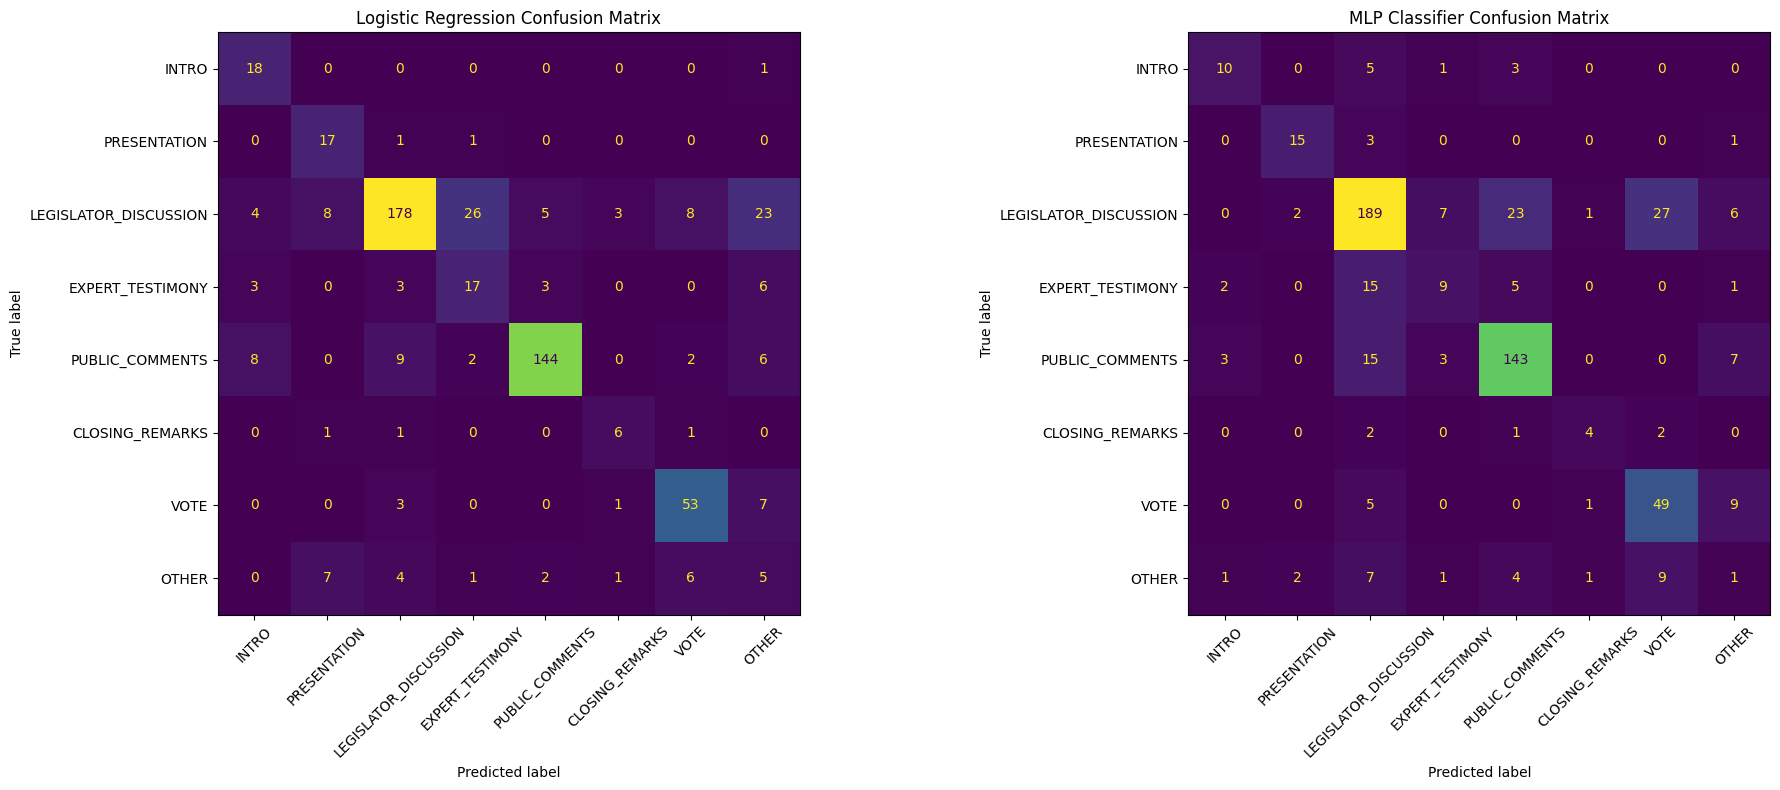

In [15]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

# Filter to only labels present in test set
labels = [label for label in label_order if label in y_test.unique()]

# Create side-by-side confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Logistic Regression confusion matrix
ConfusionMatrixDisplay.from_predictions(
    y_test,
    pred_lr,
    labels=labels,
    xticks_rotation=45,
    ax=axes[0],
    colorbar=False,
)
axes[0].set_title('Logistic Regression Confusion Matrix')

# MLP confusion matrix
ConfusionMatrixDisplay.from_predictions(
    y_test,
    pred_mlp,
    labels=labels,
    xticks_rotation=45,
    ax=axes[1],
    colorbar=False,
)
axes[1].set_title('MLP Classifier Confusion Matrix')

plt.tight_layout()
plt.show()

In [16]:
# Use the Logistic Regression parser's predict_hearing_sections method
labels_lr = parser_lr.predict_hearing_sections(
    hearing=sampled_hearings[0],
    utterances_df=utterances_df,
    smooth=True,
)

print("Logistic Regression predictions:")
print(labels_lr)

print("\n" + "=" * 80 + "\n")

# Use the MLP parser's predict_hearing_sections method
labels_mlp = parser_mlp.predict_hearing_sections(
    hearing=sampled_hearings[0],
    utterances_df=utterances_df,
    smooth=True,
)

print("MLP Classifier predictions:")
print(labels_mlp)

Logistic Regression predictions:
['INTRO', 'PRESENTATION', 'PRESENTATION', 'PRESENTATION', 'PRESENTATION', 'LEGISLATOR_DISCUSSION', 'OTHER', 'OTHER', 'OTHER', 'OTHER', 'OTHER', 'OTHER', 'OTHER', 'OTHER', 'OTHER', 'OTHER', 'OTHER', 'OTHER', 'OTHER', 'PUBLIC_COMMENTS', 'PUBLIC_COMMENTS', 'PUBLIC_COMMENTS', 'PUBLIC_COMMENTS', 'PUBLIC_COMMENTS', 'PUBLIC_COMMENTS', 'LEGISLATOR_DISCUSSION', 'LEGISLATOR_DISCUSSION', 'LEGISLATOR_DISCUSSION', 'VOTE', 'VOTE', 'VOTE', 'VOTE', 'CLOSING_REMARKS', 'LEGISLATOR_DISCUSSION', 'VOTE', 'VOTE', 'VOTE', 'VOTE', 'VOTE', 'VOTE', 'VOTE', 'VOTE']


MLP Classifier predictions:
['INTRO', 'PRESENTATION', 'PRESENTATION', 'PRESENTATION', 'LEGISLATOR_DISCUSSION', 'LEGISLATOR_DISCUSSION', 'LEGISLATOR_DISCUSSION', 'LEGISLATOR_DISCUSSION', 'PUBLIC_COMMENTS', 'PUBLIC_COMMENTS', 'PUBLIC_COMMENTS', 'PUBLIC_COMMENTS', 'PUBLIC_COMMENTS', 'PUBLIC_COMMENTS', 'PUBLIC_COMMENTS', 'PUBLIC_COMMENTS', 'PUBLIC_COMMENTS', 'PUBLIC_COMMENTS', 'PUBLIC_COMMENTS', 'PUBLIC_COMMENTS', 'PUBLI

In [17]:
special_hearing = None
for h in sampled_hearings:
  if h.bid == 'CA_201720180AB2721':
    special_hearing = h
    break

Note: special case of Chairman presenting to someone else: Bill ID CA_201720180SB1293

Special kind of bill discussion: CA_201720180AB1708
Case where you have to use handoff cue: CA_201720180AB2721
CA_201720180SCR159

# Sanity Checks

In [18]:
print(sampled_hearings[0])

State:		CA
Committee:	Senate Standing Committee on Governance and Finance
Bill:		CA_201720180SCA22
Date:		2018-05-09


Transcript:
Mike McGuire: [PRESIDING_CHAIR]:
we're moving to BILL which is a constitutional amendment 22 senator BILL_AUTHOR this is in regards to school districts and parcel taxes we welcome the good senator the chair of education to the ORG the floor is yours sir


Benjamin Allen: [BILL_AUTHOR]:
members many of you know that I came to this position having served for two terms on school board in my hometown of GPE and I was elected in 2008 and literally I think that I was on the ballot for the november election and in october the stock market crashed the subprime mortgage hit full disaster mode and basically my entire time on the school board was spent trying to figure out ways to balance the budget keep our financial controls in place while also making sure we did everything we could to preserve and protect the core programs that made such a difference for our commun

In [19]:
def pprint_hearing_labels(hearing, utterances_df, labeled_utterances_df, parser, model_name=""):
  """Print formatted transcript with predicted section labels.
  
  Args:
      hearing: The hearing to print
      utterances_df: DataFrame with utterance features
      labeled_utterances_df: DataFrame with ground truth labels
      parser: HearingParser instance with trained model
      model_name: Name of the model for display purposes
  """
  pred_labels = parser.predict_hearing_sections(
    hearing=hearing,
    utterances_df=utterances_df,
    smooth=True,
  )
  
  # Filter labeled_utterances_df for this specific hearing
  hearing_labels = labeled_utterances_df[
    (labeled_utterances_df['bid'] == hearing.bid) & 
    (labeled_utterances_df['hid'] == hearing.hid)
  ].sort_values('uid')
  
  true_labels = hearing_labels['section'].values

  print()
  if model_name:
    print(f"Model: {model_name}")
  print(f"State:\t\t{hearing.state}")
  print(f"Committee:\t{hearing.cname}")
  print(f"Bill:\t\t{hearing.bid}")
  print(f"Date:\t\t{hearing.hearing_date.strftime('%Y-%m-%d')}")
  print()
  print("Transcript:")
  for i, contribution in enumerate(hearing.utterances):
    speaker = hearing.speakers[contribution.pid]
    print(f'Predicted label:\t[{pred_labels[i] if i < len(pred_labels) else "UNKNOWN"}]')
    print(f'True label:\t\t[{true_labels[i] if i < len(true_labels) else "UNKNOWN"}]')
    first_name = speaker.first_name or "UNKNOWN"
    last_name = speaker.last_name or "UNKNOWN"
    role = "UNKNOWN"
    if speaker.speaker_position:
      role = speaker.speaker_position.name
    name = f"{first_name} {last_name} [{role}]:"
    print(f"{name:<20}")
    print(f"\t{contribution.text}")
    print()
  print()

In [20]:
print("=" * 80)
print("LOGISTIC REGRESSION MODEL")
print("=" * 80)
pprint_hearing_labels(sampled_hearings[1], utterances_df, labeled_utterances_df, parser_lr, "Logistic Regression")

print("\n" + "=" * 80)
print("MLP CLASSIFIER MODEL")
print("=" * 80)
pprint_hearing_labels(sampled_hearings[1], utterances_df, labeled_utterances_df, parser_mlp, "MLP Classifier")

LOGISTIC REGRESSION MODEL

Model: Logistic Regression
State:		CA
Committee:	Assembly Standing Committee on Education
Bill:		CA_201720180AB2601
Date:		2018-03-21

Transcript:
Predicted label:	[LEGISLATOR_DISCUSSION]
True label:		[PRESENTATION]
Shirley Weber [COMMITTEE_MEMBER]:
	good afternoon mr chair and members i'm here to present to you BILL which extends ORG it's comprehensive sex education and HIV prevention mandates on traditional public schools to charter schools at the time when we presented the first bill in terms of the healthy youth act it was not ever my thought that it would not apply to all schools because sex education; healthy education is something that every child should have to me it's as fundamental as reading and writing and math and the sciences and but others had a tendency to not see it because we didn't call it out even though we said it was for public schools we didn't call it out and so therefore BILL exists today to ensure that GPE charter school students rec